In [ ]:
# Importa bibliotecas
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn import datasets
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary


In [ ]:
m = 1500

# Gerando os dados
data = datasets.make_moons(n_samples=m, noise=0.2)
X, Y = data
X = torch.tensor(X, dtype=torch.float32)  # Convertendo as características de entrada para um tensor PyTorch
Y = torch.tensor(Y, dtype=torch.float32).view(m, 1)  # Convertendo os pontos para um tensor PyTorch e dimensionando para ter a forma (m,1)
#Y = Y.view(m, 1)  # Redimensionando Y para ter a forma (m, 1)


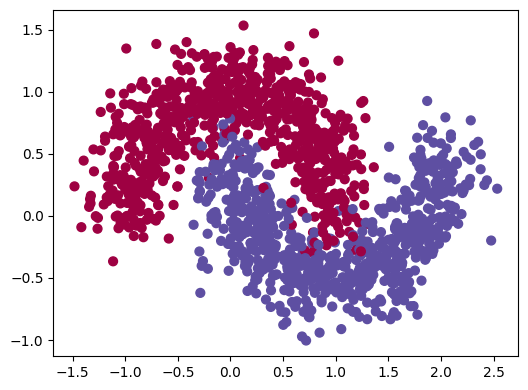

In [ ]:

plt.figure(figsize=(6, 4.5))
# Convertendo os tensores PyTorch para arrays NumPy para plotar.
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=Y.view(-1).numpy(), s=40, cmap=plt.cm.Spectral)
plt.show()

In [ ]:
# Separação em conjuntos de treino e validação
m_train = 800
m_val = 200

# Criando conjuntos de treino, validação e teste
train_dataset = TensorDataset(X[:m_train], Y[:m_train])
val_dataset = TensorDataset(X[m_train:m_train+m_val], Y[m_train:m_train+m_val])
test_dataset = TensorDataset(X[m_train+m_val:], Y[m_train+m_val:])


In [ ]:
# inicializa gerador de números aleatórios
torch.manual_seed(1)

# Definição da rede neural no PyTorch
class RedeNeural(nn.Module):
    def __init__(self):
        super(RedeNeural, self).__init__()
        self.layer1 = nn.Linear(X[:m_train].shape[1], 20)  # Camada densa com 10 neurônios
        self.layer2 = nn.Linear(20, 20)  # Camada densa com 10 neurônios
        self.layer3 = nn.Linear(20, 1)   # Camada de saída com 1 neurônio

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        # Dropout de 10% para evitar overfitting
        x = nn.Dropout(0.1)(x)
        x = torch.tanh(self.layer2(x))
        # Dropout de 10% para evitar overfitting
        x = nn.Dropout(0.1)(x)
        #x = torch.sigmoid(self.layer3(x))
        x = self.layer3(x)
        return x

# Visualização da Rede
rna = RedeNeural()
summary(rna, input_size=(X[:m_train].shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 20]              60
            Linear-2                   [-1, 20]             420
            Linear-3                    [-1, 1]              21
Total params: 501
Trainable params: 501
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [ ]:
otimizador = optim.Adam(rna.parameters())  # Otimizador Adam
criterio = nn.BCEWithLogitsLoss()  # Função de perda de entropia cruzada binária

# Dataloaders para treinamento e validação
train_loader = DataLoader(train_dataset, batch_size=40, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=40)

custo = []
custo_val = []
exatidao = []
exatidao_val = []

# Função para calcular a exatidão
def binary_accuracy(outputs, labels):
    with torch.no_grad():
        preds = torch.sigmoid(outputs) >= 0.5
        correct = (preds == labels).float().sum()
        accuracy = correct / labels.numel()
    return accuracy.item()

# Treinamento e validação da rede
for epoch in range(200):  # Loop sobre o conjunto de dados

    rna.train()  # Define o modelo para o modo de treinamento
    train_correct = 0
    train_total = 0
    running_loss_train = 0.0

    for inputs, labels in train_loader:
        # Zerar os gradientes dos parâmetros
        otimizador.zero_grad()

        # Forward
        outputs = rna(inputs)
        loss = criterio(outputs, labels)

        # Backward + optimizador
        loss.backward()
        otimizador.step()

        running_loss_train += loss.item()
        train_accuracy = binary_accuracy(outputs, labels)

    # Avaliação do modelo usando o conjunto de validação

    rna.eval()  # Define o modelo para o modo de avaliação
    val_correct = 0
    val_total = 0
    running_loss_val = 0.0

    with torch.no_grad():  # Desativa o cálculo de gradiente
        for inputs, labels in val_loader:
            outputs = rna(inputs)
            loss_val = criterio(outputs, labels)
            running_loss_val += loss_val.item()
            val_accuracy = binary_accuracy(outputs, labels)

    custo.append(running_loss_train / len(train_loader))
    custo_val.append(running_loss_val / len(val_loader))
    exatidao_val.append(val_accuracy)
    exatidao.append(train_accuracy)


    # Printar estatísticas do treinamento e validação
    print(f'Epoch {epoch + 1}, '
          f'Train Loss: {running_loss_train / len(train_loader):.4f}, '
          f'Train Accuracy: {train_accuracy:.4f}, '
          f'Validation Loss: {running_loss_val / len(val_loader):.4f}, '
          f'Validation Accuracy: {val_accuracy:.4f}')
epocas = range(1, len(custo) + 1)


Epoch 1, Train Loss: 0.6406, Train Accuracy: 0.8500, Validation Loss: 0.5963, Validation Accuracy: 0.8250
Epoch 2, Train Loss: 0.5679, Train Accuracy: 0.7750, Validation Loss: 0.5346, Validation Accuracy: 0.8000
Epoch 3, Train Loss: 0.5073, Train Accuracy: 0.9000, Validation Loss: 0.4746, Validation Accuracy: 0.8000
Epoch 4, Train Loss: 0.4546, Train Accuracy: 0.8500, Validation Loss: 0.4290, Validation Accuracy: 0.8000
Epoch 5, Train Loss: 0.4175, Train Accuracy: 0.6500, Validation Loss: 0.4011, Validation Accuracy: 0.8000
Epoch 6, Train Loss: 0.3830, Train Accuracy: 0.7500, Validation Loss: 0.3670, Validation Accuracy: 0.8000
Epoch 7, Train Loss: 0.3633, Train Accuracy: 0.8250, Validation Loss: 0.3544, Validation Accuracy: 0.8000
Epoch 8, Train Loss: 0.3397, Train Accuracy: 0.8500, Validation Loss: 0.3469, Validation Accuracy: 0.8000
Epoch 9, Train Loss: 0.3270, Train Accuracy: 0.9000, Validation Loss: 0.3346, Validation Accuracy: 0.8250
Epoch 10, Train Loss: 0.3123, Train Accuracy: 

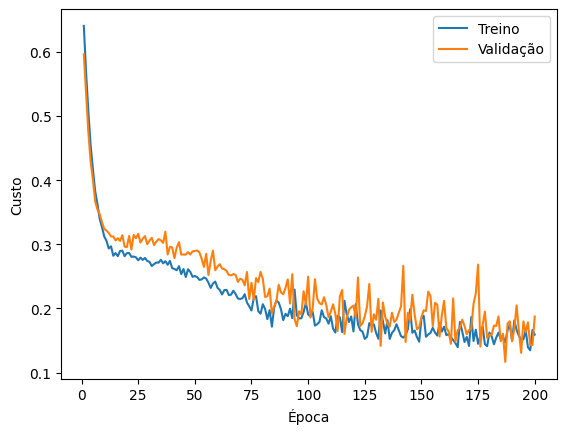

In [ ]:
# Gráfico do custo em função das épocas
plt.plot(epocas, custo, label='Treino')
plt.plot(epocas, custo_val, label='Validação')
plt.legend()
plt.xlabel('Época')
plt.ylabel('Custo')
plt.show()

Text(0, 0.5, 'Exatidão')

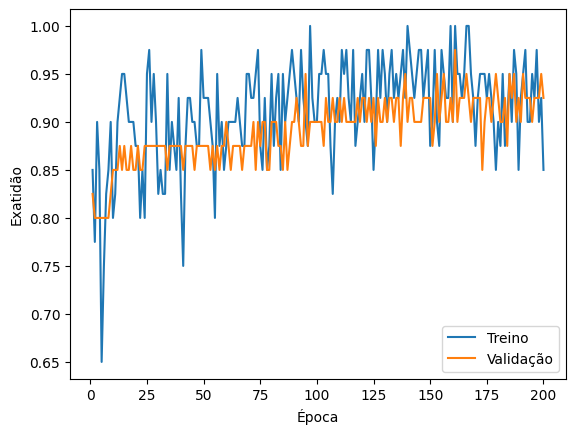

In [ ]:
# Gráfico da exatidão em função das épocas
plt.plot(epocas,exatidao,label='Treino')
plt.plot(epocas,exatidao_val,label='Validação')
plt.legend()
plt.xlabel('Época')
plt.ylabel('Exatidão')

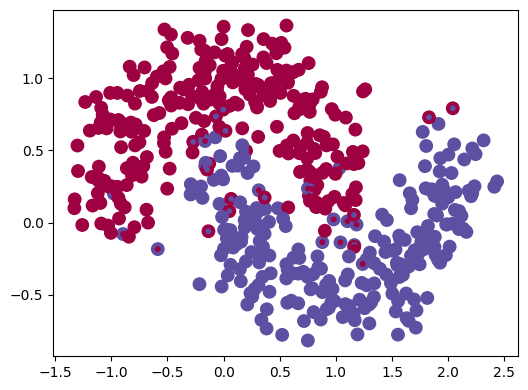

In [ ]:
rna.eval()  # Coloca o modelo em modo de avaliação

# Fazendo previsões com PyTorch
with torch.no_grad():  # Desativa o cálculo de gradiente
    Y_test_pred = rna(X[m_train+m_val:])
    Y_test_pred_prob = torch.sigmoid(Y_test_pred) #trasnforma as saídas em probabilidades (número entre 0 e 1)
    Y_test_pred_int = torch.round(Y_test_pred_prob) # Arredonda as saídas para 0 ou 1

# Plotando as previsões em comparação com os pontos verdadeiros
plt.figure(figsize=(6, 4.5))
plt.scatter(X[m_train+m_val:][:, 0].numpy(), X[m_train+m_val:][:, 1].numpy(), c=Y_test_pred_int.numpy().ravel(), s=80, cmap=plt.cm.Spectral)
plt.scatter(X[m_train+m_val:][:, 0].numpy(), X[m_train+m_val:][:, 1].numpy(), c=Y[m_train+m_val:].numpy().ravel(), s=10, cmap=plt.cm.Spectral)
plt.show()
